<a href="https://colab.research.google.com/github/palarunava/machine-learning-courses/blob/main/udacity-intro-to-tf-for-dl/flowers_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# _URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
IMG_WIDTH = 150
IMG_HEIGHT = 150

def resize_function(image, label):
  # Resize the image to the target size
  image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
  # Normalize the image to [0, 1] range
  image = tf.cast(image, tf.float32) / 255.0
  return image, label

ds, ds_info = tfds.load(
  'tf_flowers',
  split='train',
  with_info=True,
  as_supervised=True
)

# print(f'Number of samples: {ds_info.splits['train'].num_examples}')
print(f'Number of samples: {ds.cardinality()}')

# Apply the transformation to your tf.data.Dataset object
# Use num_parallel_calls for faster execution
ds = ds.map(
    resize_function,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_size = int(0.8 * ds.cardinality().numpy())
# valid_size = ds.cardinality() - train_size

train_ds = ds.take(train_size)
valid_ds = ds.skip(train_size)

Number of samples: 3670


In [17]:
def display_images(ds, num_images=50):
  random_subset = ds.shuffle(buffer_size=1000, seed=52).take(num_images)
  classes = ds_info.features['label'].names

  num_images_per_row = 5
  num_rows = num_images // num_images_per_row
  image_size = 3

  f, axarr = plt.subplots(num_rows, num_images_per_row, figsize=(image_size * num_images_per_row, image_size * num_rows))

  i = j = 0
  for image, label in random_subset:
    axarr[i,j].imshow(image)
    axarr[i,j].set_title(f'{classes[label.numpy()]}', fontsize=10)
    axarr[i,j].axis('off')
    j += 1
    if j == num_images_per_row:
      i += 1
      j = 0

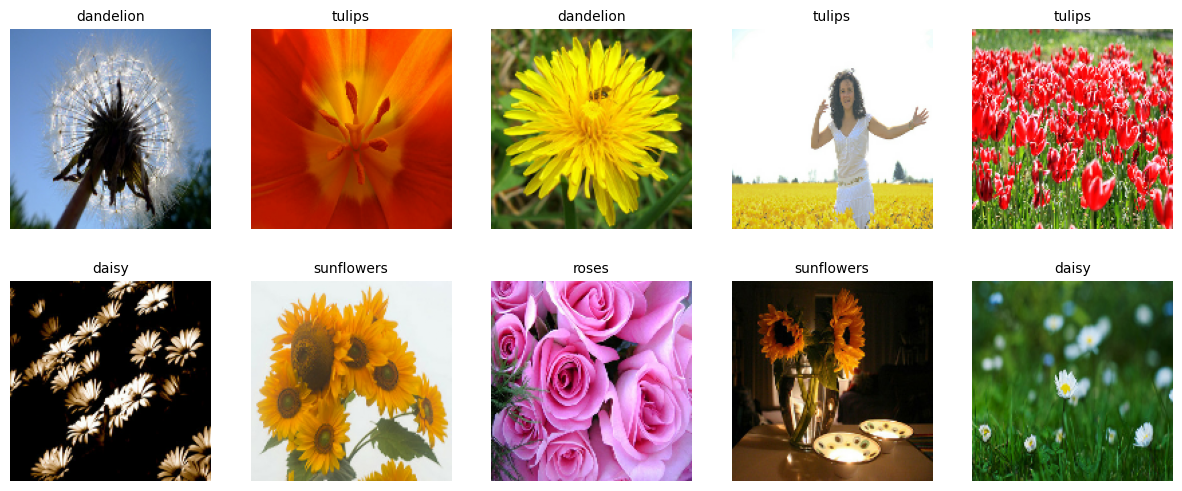

In [56]:
display_images(train_ds, num_images=10)

In [38]:
def augment_dataset(ds):
  # Create a dedicated augmentation pipeline
  data_augmentation = tf.keras.Sequential([
      # tf.keras.layers.Rescaling(1./255),
      tf.keras.layers.RandomFlip("horizontal_and_vertical"),
      tf.keras.layers.RandomRotation(0.2),
      tf.keras.layers.RandomZoom(0.1),
      # tf.keras.layers.RandomContrast(0.1)
  ])

  AUTOTUNE = tf.data.AUTOTUNE
  BATCH_SIZE = 32

  # Complete optimized pipeline
  augmented_dataset = (
      ds
      # 1. CACHE first (saves raw, un-augmented images to RAM)
      .cache()

      # 2. SHUFFLE next (perfectly randomizes individual image order)
      .shuffle(buffer_size=ds.cardinality())

      # 3. BATCH third (groups the shuffled images into chunks)
      .batch(BATCH_SIZE)

      # 4. MAP augmentation (applies random flips/rotations to the entire batch)
      .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

      # 5. PREFETCH last (keeps the GPU fed constantly)
      .prefetch(buffer_size=AUTOTUNE)
  )
  return augmented_dataset

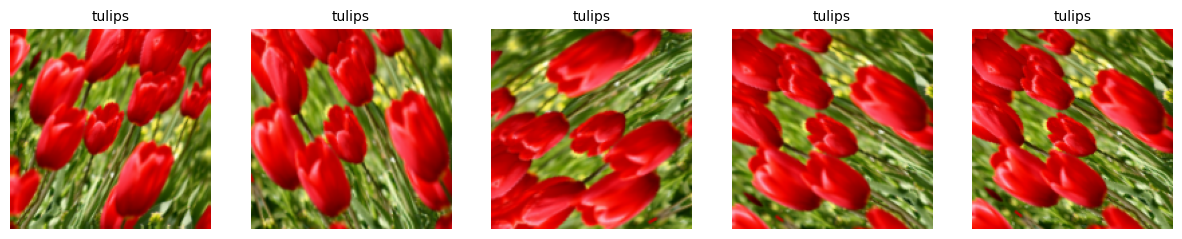

In [57]:
augmented_dataset = augment_dataset(train_ds.take(1).repeat(5))
classes = ds_info.features['label'].names
# display_images(augmented_dataset.unbatch(), num_images=5)

f, axarr = plt.subplots(1, 5, figsize=(15, 3))

i = 0
for image, label in augmented_dataset.unbatch():
  axarr[i].imshow(image)
  axarr[i].set_title(f'{classes[label.numpy()]}', fontsize=10)
  axarr[i].axis('off')
  i += 1
  if i >= 5:
    break

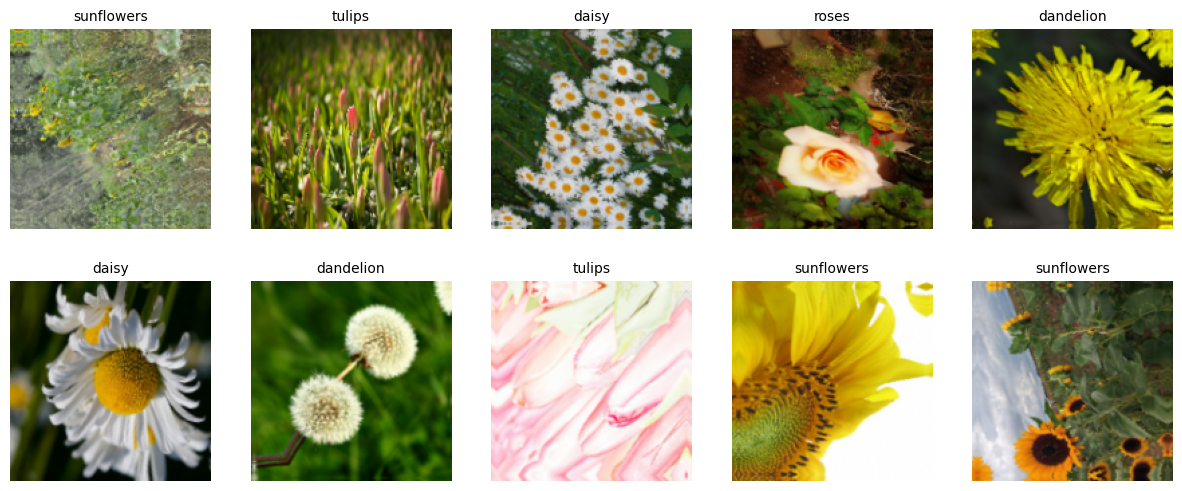

In [58]:
augmented_dataset = augment_dataset(train_ds)
display_images(augmented_dataset.unbatch(), num_images=10)

In [ ]:
model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  tf.keras.layers.MaxPooling2D(2, 2),

  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(2,2),

  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(512, activation='relu'),
  tf.keras.layers.Dense(2)
])